# How Penn Shapes Local Economies:

### Business Distribution Near Campus vs. Outside University City:
---

This dataset examines how business composition varies between the area surrounding University of Pennsylvania and neighborhoods outside University City. Using a 1000M radius to define the campus-adjacent zone, the comparison reveals how universities influence the types of businesses that cluster nearby.

First, we are going to load in the Philly business data:

In [32]:
import pandas as pd

In [3]:
df = pd.read_csv("business_licenses.csv", low_memory=False)

In [4]:
df.columns

Index(['the_geom', 'the_geom_webmercator', 'objectid', 'posse_jobid',
       'addressobjectid', 'council_district', 'address', 'unit_type',
       'unit_num', 'zip', 'censustract', 'parcel_id_num', 'opa_account_num',
       'opa_owner', 'owneroccupied', 'addressed_license', 'licensenum',
       'revenuecode', 'licensetype', 'rentalcategory', 'initialissuedate',
       'mostrecentissuedate', 'expirationdate', 'inactivedate',
       'licensestatus', 'numberofunits', 'legalfirstname', 'legallastname',
       'legalname', 'legalentitytype', 'business_name',
       'business_mailing_address', 'ownercontact1name',
       'ownercontact1mailingaddress', 'ownercontact1city',
       'ownercontact1state', 'ownercontact1zippostalcode', 'ownercontact2name',
       'ownercontact2mailingaddress', 'ownercontact2city',
       'ownercontact2state', 'ownercontact2zippostalcode', 'geocode_x',
       'geocode_y', 'gdb_geomattr_data', 'ownerismanagingagentinphilly',
       'cal_number', 'lat', 'lng'],
     

In [5]:
df['zip'] = df['zip'].astype(str).str[:5]

In [7]:
universitycity_zip = ['19104']

uc_df = df[df['zip'].isin(universitycity_zip)]

In [12]:
print("Total number of businesses in University City:", len(uc_df))

Total number of businesses in University City: 12391


In [18]:
active_uc_df = uc_df[uc_df['licensestatus'] == 'Active']
len(active_uc_df)

4236

In [19]:
outside_uc_df = df[~df['zip'].isin(universitycity_zip)]
active_outside_uc_df = outside_uc_df[outside_uc_df['licensestatus'] == 'Active']

print("University City:", len(active_uc_df))
print("Outside University City:", len(active_outside_uc_df))

University City: 4236
Outside University City: 108696


As we can see, there are an abundance of different businesses and types in University City and beyond. While University City contains a much smaller share of total businesses compared to the rest of Philadelphia, this difference reflects its more limited geographic size rather than a lack of economic activity.

Next, we are going to dive into specific business types within University City:

In [27]:
active_uc_df['licensetype'].value_counts().head(10)

licensetype
Rental                                           3235
Dumpster License - Private Property               358
Food Preparing and Serving                        181
Food Preparing and Serving (30+ SEATS)            131
Vacant Residential Property / Lot                  83
Hazardous Materials                                55
High Rise                                          38
Food Establishment, Retail Permanent Location      34
Limited Lodging Operator                           28
Sidewalk Cafe                                      14
Name: count, dtype: int64

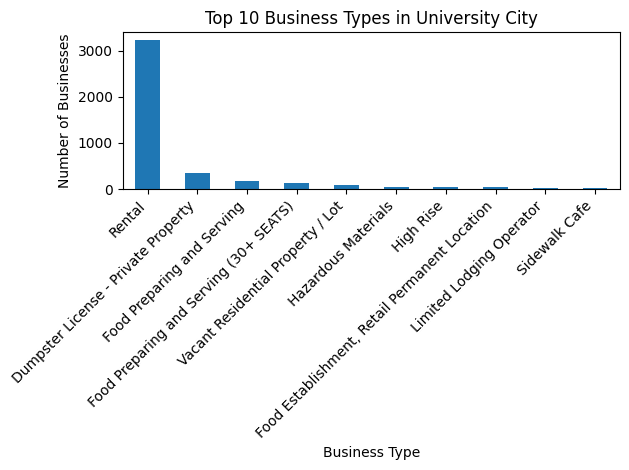

In [30]:
import matplotlib.pyplot as plt

plt.figure()
type_counts = active_uc_df['licensetype'].value_counts().head(10)
type_counts.plot(kind='bar')

plt.title("Top 10 Business Types in University City")
plt.xlabel("Business Type")
plt.ylabel("Number of Businesses")

plt.xticks(rotation=45, ha='right')  # rotate labels so they fit
plt.tight_layout()

plt.show()

In [139]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import Point

plot_df = active_uc_df.dropna(subset=['lat', 'lng']).copy()

business_gdf = gpd.GeoDataFrame(
    plot_df,
    geometry=gpd.points_from_xy(plot_df['lng'], plot_df['lat']),
    crs="EPSG:4326"
)

In [140]:
business_gdf = business_gdf.to_crs(epsg=3857)

In [141]:
campus_df = gpd.GeoDataFrame(
    {
        "name": ["Penn", "Drexel"],
        "lat": [39.9522, 39.9566],
        "lng": [-75.1932, -75.1899]
    },
    geometry=gpd.points_from_xy([-75.1932, -75.1899], [39.9522, 39.9566]),
    crs="EPSG:4326"
).to_crs(epsg=3857)

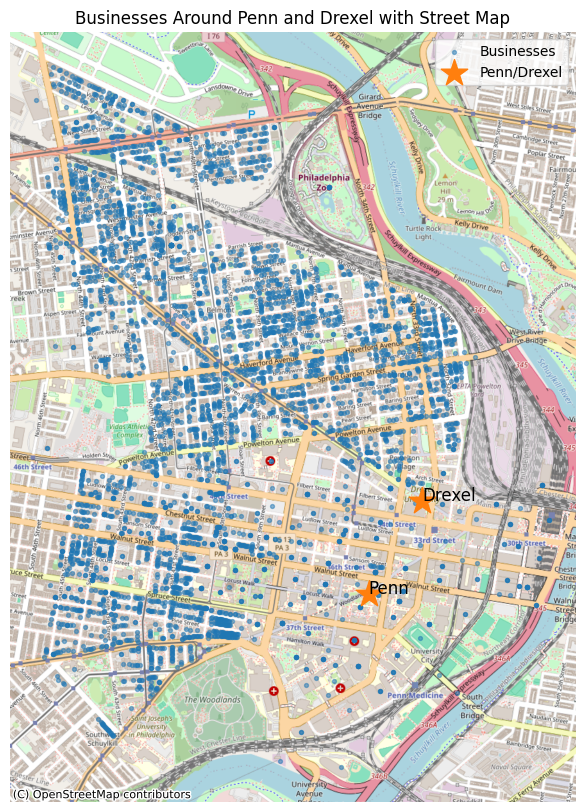

In [142]:
fig, ax = plt.subplots(figsize=(12, 10))

business_gdf.plot(
    ax=ax,
    markersize=8,
    alpha=0.5,
    label="Businesses"
)

campus_df.plot(
    ax=ax,
    marker="*",
    markersize=400,
    label="Penn/Drexel"
)

for x, y, label in zip(campus_df.geometry.x, campus_df.geometry.y, campus_df["name"]):
    ax.text(x, y, label, fontsize=12)

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title("Businesses Around Penn and Drexel with Street Map")
ax.set_axis_off()
ax.legend()

plt.show()

There are so many businesses that are cultivated surrounding Penn and Drexel's campus.

Next, we are going to examine the types of businesses soley surrounding Penn's campus by creating a 1000m radius stemming from the most central place on Penn's campus: Locust Walk, near the LOVE sign. This buffer captures the immediate commercial environment accessible within a short walking distance.

In [143]:
penn_buffer = campus_df[campus_df["name"] == "Penn"].geometry.buffer(1000)
near_penn = business_gdf[business_gdf.within(penn_buffer.iloc[0])]

In [144]:
def categorize(lic):
    lic = str(lic).lower()
    
    # Housing
    if any(x in lic for x in ["rental", "lodging", "residential", "high rise"]):
        return "Housing"
    
    # FOOD
    elif any(x in lic for x in ["food", "cafe", "restaurant", "eat", "streetery"]):
        return "Food & Dining"
    
    # Infrastructure
    elif any(x in lic for x in ["dumpster", "hazardous"]):
        return "Infrastructure"
    
    # Retail & Services 
    elif any(x in lic for x in ["retail", "repair", "dealer", "child", "games", "handbill"]):
        return "Retail & Services"
    
    # Transport
    elif any(x in lic for x in ["parking", "garage", "vehicle"]):
        return "Parking/Transport"
    
    # Permits
    elif any(x in lic for x in ["permit", "assembly"]):
        return "Permits & Regulation"
    
    # Vacant
    elif "vacant" in lic:
        return "Vacant"
    
    else:
        return "Other"

In [145]:
near_penn['category'] = near_penn['licensetype'].apply(categorize)

In [146]:
category_counts = near_penn['category'].value_counts(normalize=True)
print(category_counts)

category
Infrastructure          0.354911
Housing                 0.328125
Food & Dining           0.290179
Parking/Transport       0.011161
Permits & Regulation    0.008929
Retail & Services       0.006696
Name: proportion, dtype: float64


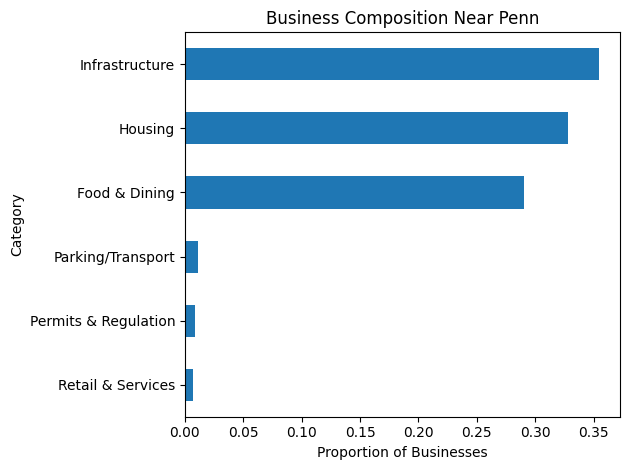

In [147]:
import matplotlib.pyplot as plt

plt.figure()

category_counts.sort_values().plot(kind='barh')

plt.title("Business Composition Near Penn")
plt.xlabel("Proportion of Businesses")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

The distribution of business licenses within a 1000M radius of Penn reveals a highly concentrated and purpose-driven local economy. Infrastructure-related licenses constitute the largest share, followed closely by housing and food and dining establishments. This pattern suggests that the area is structured primarily to support a dense, student-centered population. Housing dominates due to the demand for student accommodation, while the significant presence of food establishments reflects the daily consumption and social habits of students. The prominence of infrastructure licenses, such as waste management and hazardous materials, further indicates the operational demands of maintaining a high-density urban environment. In contrast, categories such as retail, transportation, and regulatory permits make up only a minimal portion of the total, highlighting the limited economic diversity in the immediate vicinity of campus.

Finally, we are going to compare the types of businesses that remain prevalent in University City in comparison to business types all throughout Philadelphia.

In [148]:
outside_uc = df[~df['zip'].isin(['19104'])].copy()

In [149]:
outside_uc['category'] = outside_uc['licensetype'].apply(categorize)

In [150]:
outside_counts = outside_uc['category'].value_counts(normalize=True)
print(outside_counts)

category
Housing                 0.758562
Food & Dining           0.118755
Infrastructure          0.056239
Other                   0.030918
Retail & Services       0.027523
Parking/Transport       0.005924
Permits & Regulation    0.001611
Vacant                  0.000468
Name: proportion, dtype: float64


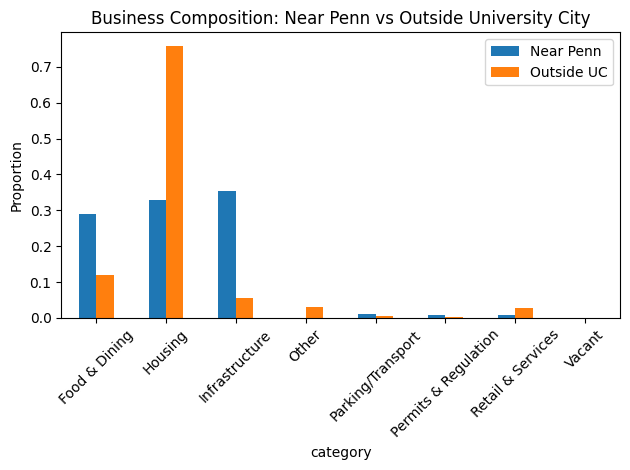

In [151]:
comparison.plot(kind='bar')

plt.title("Business Composition: Near Penn vs Outside University City")
plt.ylabel("Proportion")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

A comparison of business composition reveals a clear distinction between the area surrounding Penn and neighborhoods outside University City. While areas outside University City are overwhelmingly dominated by housing, accounting for the vast majority of business licenses, the area within a 1000M radius of Penn exhibits a more diversified and functionally specialized economic structure. In particular, food and dining establishments and infrastructure-related licenses make up a significantly larger share near campus. This suggests that proximity to the university not only increases commercial activity but fundamentally reshapes it, shifting the local economy from predominantly residential toward one that supports student consumption and the operational demands of a dense, high-traffic environment.

Ultimately, this demonstrates how Penn and university culture impact the surrounding area.

<Figure size 640x480 with 0 Axes>

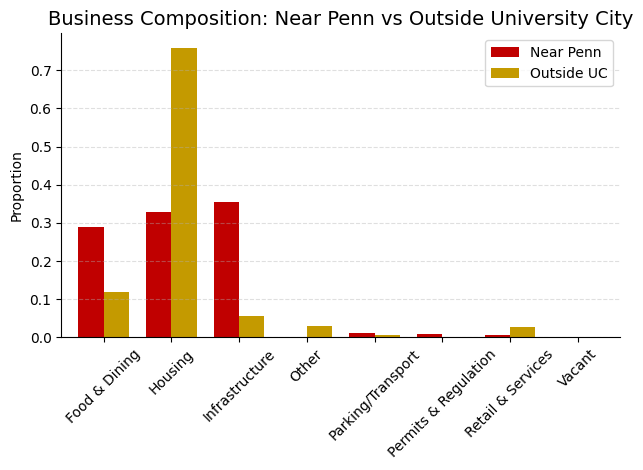

In [152]:
import matplotlib.pyplot as plt

# Colors to match your rent slide
penn_color = '#C00000'     # deep red
outside_color = '#C49A00'  # gold

plt.figure()

comparison.plot(
    kind='bar',
    color=[penn_color, outside_color],
    width=0.75
)

plt.title("Business Composition: Near Penn vs Outside University City", fontsize=14)

plt.ylabel("Proportion")
plt.xlabel("")

plt.xticks(rotation=45)

# Light grid like your rent chart
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Remove top/right borders (clean look)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.legend(["Near Penn", "Outside UC"])

plt.tight_layout()
plt.show()